# CPC353 Natural Language Processing
## Assignment 2: Stock Trend Prediction with News Sentiment
### Part 3: Stock Trend Prediction with Pre-trained Transformer

This notebook fine-tunes a pre-trained Transformer model (BERT) to predict stock trends.

**Approach:**
1. Load pre-trained BERT model and tokenizer
2. Fine-tune on stock news dataset
3. Evaluate using accuracy, precision, recall, and F1

## 1. Install and Import Libraries

In [37]:
# pip install transformers torch

In [38]:
# Install transformers library
# !pip install transformers torch

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import torch.nn as nn

import matplotlib.pyplot as plt

# Set random seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


## 2. Load and Prepare Dataset

In [39]:
# Load dataset
df = pd.read_csv(r"stock_trend.csv")

# Calculate price change and assign trend labels
df['Price_Change_Percent'] = ((df['After'] - df['Before']) / df['Before']) * 100

def assign_trend(change_percent):
    if change_percent > 10:
        return 'uptrend'
    elif change_percent < -10:
        return 'downtrend'
    else:
        return 'flat'

df['Trend'] = df['Price_Change_Percent'].apply(assign_trend)

print("Dataset loaded!")
print(f"Total samples: {len(df)}")
print(f"\nTrend Distribution:")
print(df['Trend'].value_counts())
print("\n" + "="*60)
print("First 10 rows:")
print("="*60)
df[['Title', 'Trend']].head(10)

Dataset loaded!
Total samples: 24388

Trend Distribution:
Trend
flat         22626
uptrend       1232
downtrend      530
Name: count, dtype: int64

First 10 rows:


,Title,Trend
0,100 startups participate in Maxis' Market Acce...,flat
1,16.89% stake in Subur Tiasa traded off-market,flat
2,Najib wanted 1MDB's Genting Sanyen deal sped u...,flat
3,"25bps OPR cut likely in 2H20, says Manulife",flat
4,A 25-month extension on concession pushes Phar...,flat
5,3.7% of Yong Tai transacted off-market,flat
6,"3A, Ruberex, Thriven, Kanger, UniWall",flat
7,40% stake in IWH-CREC may cost Ekovest RM1.5b,flat
8,4.41% Kronologi Asia shares traded off-market,flat
9,4.96% of MMAG traded off market,flat


## 3. Prepare Labels

In [40]:
# Label mapping
label_mapping = {'downtrend': 0, 'flat': 1, 'uptrend': 2}
reverse_mapping = {0: 'downtrend', 1: 'flat', 2: 'uptrend'}
num_labels = 3

# Prepare data
texts = df['Title'].values
labels = np.array([label_mapping[t] for t in df['Trend'].values])

print(f"Label mapping: {label_mapping}")
print(f"Number of classes: {num_labels}")

Label mapping: {'downtrend': 0, 'flat': 1, 'uptrend': 2}
Number of classes: 3


## 4. Split Data

In [41]:
# Split: 70% train, 20% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=SEED, stratify=y_temp)

print("Data split completed!")
print(f"  Training:   {len(X_train)} ({len(X_train)/len(texts)*100:.1f}%)")
print(f"  Validation: {len(X_val)} ({len(X_val)/len(texts)*100:.1f}%)")
print(f"  Test:       {len(X_test)} ({len(X_test)/len(texts)*100:.1f}%)")

print("\n" + "="*60)
print("First 10 training samples:")
print("="*60)
for i in range(10):
    print(f"{i+1}. {X_train[i][:50]}... -> {reverse_mapping[y_train[i]]}")

Data split completed!
  Training:   17071 (70.0%)
  Validation: 4880 (20.0%)
  Test:       2437 (10.0%)

First 10 training samples:
1. UEM Sunrise 2Q net profit up 73% on higher propert... -> flat
2. Myanmar ops to boost Daibochi’s FY18 earnings... -> flat
3. Public Bank, Hong Leong Bank the most defensive ag... -> flat
4. Asia Bioenergy sells entire stake in T7 Global for... -> flat
5. Power Root may rebound further, says RHB Retail Re... -> flat
6. BAT Malaysia, Sapura Energy, TNB, Texchem, Permaju... -> flat
7. IRB claims RM182.8m in income taxes from Magnum su... -> flat
8. CGS-CIMB Research lowers target price for Dialog t... -> flat
9. Metrod 1Q net profit up 12% on forex gain... -> flat
10. Public Bank falls 1.8% to lowest in five weeks... -> flat


## 5. Load Pre-trained BERT Tokenizer

In [42]:
# Load BERT tokenizer
MODEL_NAME = 'bert-base-uncased'
print(f"Loading tokenizer: {MODEL_NAME}")

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


print(f"Tokenizer loaded!")
print(f"Vocabulary size: {tokenizer.vocab_size}")

Loading tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizer loaded!
Vocabulary size: 30522


In [43]:
# Test tokenizer
print("\n" + "="*60)
print("Tokenizer Test:")
print("="*60)
sample_text = X_train[0]
tokens = tokenizer.tokenize(sample_text)
print(f"Original: {sample_text}")
print(f"Tokens: {tokens}")


Tokenizer Test:
Original: UEM Sunrise 2Q net profit up 73% on higher property development revenue
Tokens: ['u', '##em', 'sunrise', '2', '##q', 'net', 'profit', 'up', '73', '%', 'on', 'higher', 'property', 'development', 'revenue']


## 6. Create Dataset Class

In [44]:
# Maximum sequence length
MAX_LENGTH = 128

class StockNewsDataset(Dataset):
    """Custom Dataset for Stock News Classification."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize using BERT tokenizer
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print(f"Maximum sequence length: {MAX_LENGTH}")

Maximum sequence length: 128


In [45]:
# Create datasets
train_dataset = StockNewsDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = StockNewsDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = StockNewsDataset(X_test, y_test, tokenizer, MAX_LENGTH)

print("Datasets created!")
print(f"  Train dataset: {len(train_dataset)}")
print(f"  Val dataset:   {len(val_dataset)}")
print(f"  Test dataset:  {len(test_dataset)}")

Datasets created!
  Train dataset: 17071
  Val dataset:   4880
  Test dataset:  2437


In [46]:
# Create dataloaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with batch_size={BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

DataLoaders created with batch_size=16
  Train batches: 1067
  Val batches:   305
  Test batches:  153


## 7. Load Pre-trained BERT Model for Classification

In [47]:
# Load pre-trained BERT for sequence classification
print(f"Loading pre-trained model: {MODEL_NAME}")
print("This may take a few minutes...")

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)

print(f"\nModel loaded and moved to {device}!")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading pre-trained model: bert-base-uncased
This may take a few minutes...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded and moved to cuda!
Number of parameters: 109,484,547


## 8. Setup Optimizer, Scheduler, and Class Weights

In [48]:
# Training parameters
EPOCHS = 3
LEARNING_RATE = 2e-5

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)

# Total training steps
total_steps = len(train_loader) * EPOCHS

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Total training steps: {total_steps}")


weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a PyTorch Tensor and move to GPU (if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

# Define the Custom Loss Function
# This tells PyTorch: "Multiply the error by these weights"
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Weighted Loss Function Done:", weights)



Training Configuration:
  Epochs: 3
  Learning rate: 2e-05
  Batch size: 16
  Total training steps: 3201
Weighted Loss Function Done: [15.3378257   0.35928358  6.60131477]


## 9. Training Functions

In [49]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []

    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)
        logits = outputs.logits

        # Backward pass
        loss.backward()

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Store predictions
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)

    return avg_loss, accuracy


def evaluate(model, data_loader, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

            loss = criterion(outputs.logits, labels)
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)

    return avg_loss, accuracy, predictions, true_labels

print("Training functions defined!")

Training functions defined!


## 10. Fine-tune the Model

In [50]:
print("="*60)
print("FINE-TUNING BERT MODEL")
print("="*60)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)

    # Training
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    # Validation
    val_loss, val_acc, _, _ = evaluate(model, val_loader, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_bert_model.pt')
        print(f"  -> Best model saved! (Val Acc: {val_acc:.4f})")

print("\n" + "="*60)
print("Fine-tuning completed!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("="*60)

FINE-TUNING BERT MODEL

Epoch 1/3
----------------------------------------
  Train Loss: 1.0366, Train Acc: 0.8530
  Val Loss:   1.0194, Val Acc:   0.8289
  -> Best model saved! (Val Acc: 0.8289)

Epoch 2/3
----------------------------------------
  Train Loss: 0.9961, Train Acc: 0.8758
  Val Loss:   1.3483, Val Acc:   0.9221
  -> Best model saved! (Val Acc: 0.9221)

Epoch 3/3
----------------------------------------
  Train Loss: 0.8604, Train Acc: 0.9046
  Val Loss:   1.1850, Val Acc:   0.8824

Fine-tuning completed!
Best Validation Accuracy: 0.9221


## 11. Training History Visualization

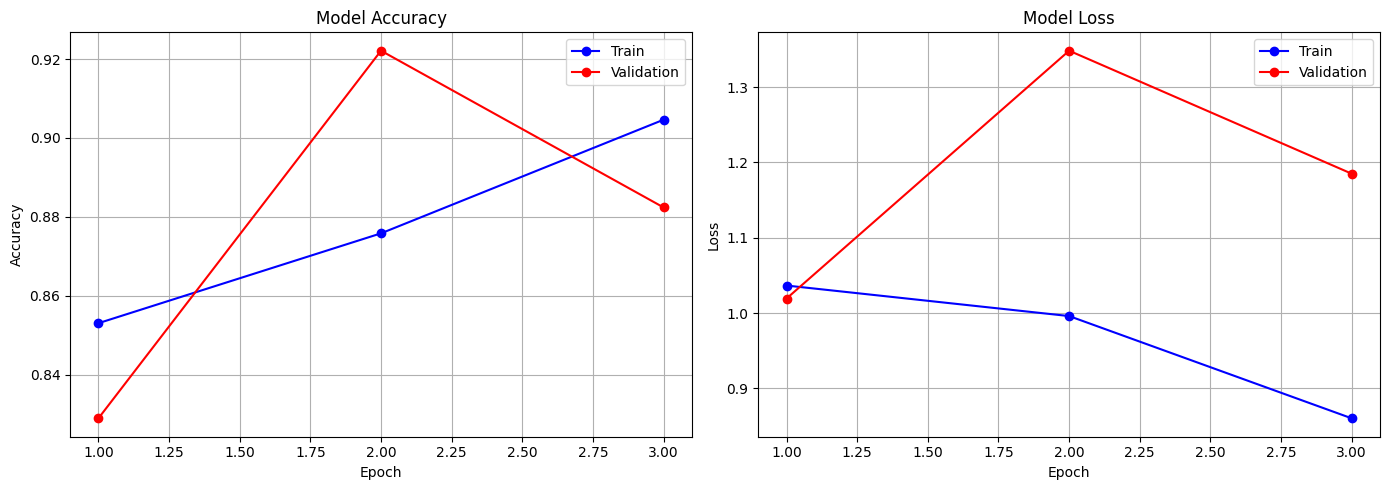

Training history saved to: transformer_training_history.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(range(1, EPOCHS+1), history['train_acc'], 'b-o', label='Train')
axes[0].plot(range(1, EPOCHS+1), history['val_acc'], 'r-o', label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(range(1, EPOCHS+1), history['train_loss'], 'b-o', label='Train')
axes[1].plot(range(1, EPOCHS+1), history['val_loss'], 'r-o', label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('transformer_training_history.png', dpi=150)
plt.show()

print("Training history saved to: transformer_training_history.png")

## 12. Load Best Model and Evaluate on Test Set

In [52]:
# Load best model
model.load_state_dict(torch.load('best_bert_model.pt'))
print("Best model loaded!")

# Evaluate on test set
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, device)

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (macro)")
print(f"Recall:    {recall:.4f} (macro)")
print(f"F1 Score:  {f1:.4f} (macro)")

Best model loaded!

TEST SET EVALUATION

Accuracy:  0.9224
Precision: 0.5204 (macro)
Recall:    0.3770 (macro)
F1 Score:  0.3960 (macro)


In [53]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred,
                            target_names=['downtrend', 'flat', 'uptrend']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   downtrend       0.29      0.04      0.07        53
        flat       0.93      0.99      0.96      2261
     uptrend       0.34      0.11      0.16       123

    accuracy                           0.92      2437
   macro avg       0.52      0.38      0.40      2437
weighted avg       0.89      0.92      0.90      2437



CONFUSION MATRIX
[[   2   49    2]
 [   5 2233   23]
 [   0  110   13]]


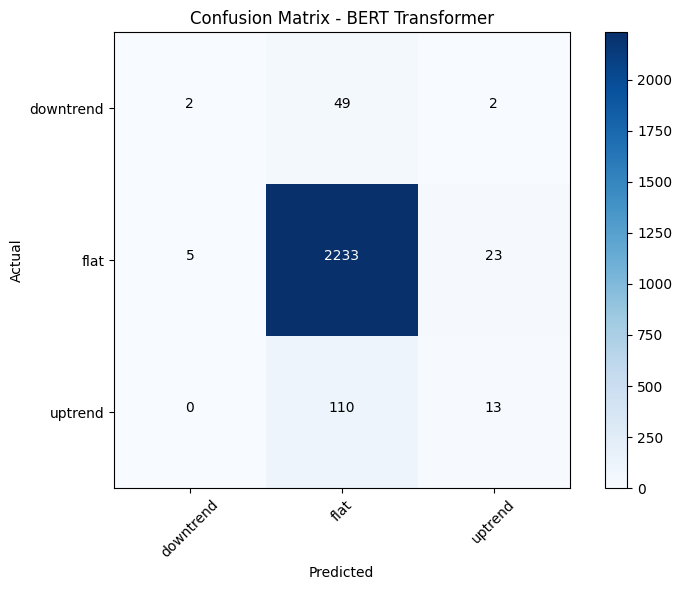

Confusion matrix saved to: transformer_confusion_matrix.png


In [54]:
print("="*60)
print("CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - BERT Transformer')
plt.colorbar()
labels = ['downtrend', 'flat', 'uptrend']
plt.xticks([0,1,2], labels, rotation=45)
plt.yticks([0,1,2], labels)
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i,j], ha='center', color=color)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('transformer_confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved to: transformer_confusion_matrix.png")

## 13. Sample Predictions

In [55]:
print("="*60)
print("SAMPLE PREDICTIONS (First 10 test samples)")
print("="*60)

for i in range(min(10, len(X_test))):
    actual = reverse_mapping[y_true[i]]
    predicted = reverse_mapping[y_pred[i]]
    mark = "CORRECT" if actual == predicted else "WRONG"

    print(f"\n{i+1}. {X_test[i][:60]}...")
    print(f"   Actual: {actual:10s} | Predicted: {predicted:10s} | {mark}")

SAMPLE PREDICTIONS (First 10 test samples)

1. Eco World International completes stage one of UK land buy...
   Actual: flat       | Predicted: flat       | CORRECT

2. Property market to recover in coming years, says Sime Darby ...
   Actual: flat       | Predicted: flat       | CORRECT

3. GHL Systems 4Q net profit up 11.5% as overseas contribution ...
   Actual: flat       | Predicted: flat       | CORRECT

4. AZRB, Diversified Gateway, Formosa Prosonic, Hiap Teck, Lust...
   Actual: flat       | Predicted: flat       | CORRECT

5. Messrs CAS Malaysia resigns as external auditor of Key ASIC ...
   Actual: flat       | Predicted: flat       | CORRECT

6. Public Bank 3Q net profit at RM1.4b...
   Actual: flat       | Predicted: flat       | CORRECT

7. Luster Industries proposes diversification into property, co...
   Actual: flat       | Predicted: flat       | CORRECT

8. Ewein active, rises 7.04% on Tabung Harapan contribution...
   Actual: uptrend    | Predicted: flat       | WRON

## 14. Prediction Function for New Text

In [56]:
def predict_trend(text, model, tokenizer, device, max_length=128):
    """Predict trend for a single news headline."""
    model.eval()

    # Tokenize
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(logits, dim=1).item()

    return reverse_mapping[pred], probs.cpu().numpy()[0]

print("Prediction function defined!")

Prediction function defined!


In [57]:
# Test prediction on new headlines
print("="*60)
print("TESTING PREDICTION ON NEW HEADLINES")
print("="*60)

test_headlines = [
    "Company reports record profits and announces expansion plans",
    "Stock prices remain stable amid market uncertainty",
    "Major losses reported as company faces bankruptcy"
]

for headline in test_headlines:
    pred_class, probs = predict_trend(headline, model, tokenizer, device)
    print(f"\nHeadline: {headline}")
    print(f"Prediction: {pred_class}")
    print(f"Probabilities: downtrend={probs[0]:.3f}, flat={probs[1]:.3f}, uptrend={probs[2]:.3f}")

TESTING PREDICTION ON NEW HEADLINES

Headline: Company reports record profits and announces expansion plans
Prediction: flat
Probabilities: downtrend=0.044, flat=0.870, uptrend=0.085

Headline: Stock prices remain stable amid market uncertainty
Prediction: flat
Probabilities: downtrend=0.017, flat=0.938, uptrend=0.045

Headline: Major losses reported as company faces bankruptcy
Prediction: flat
Probabilities: downtrend=0.034, flat=0.916, uptrend=0.050


## 15. Summary

In [58]:
print("="*60)
print("PART 3 SUMMARY")
print("="*60)

print("\n1. PRE-TRAINED MODEL:")
print(f"   - Model: {MODEL_NAME}")
print(f"   - Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   - Fine-tuned for: {num_labels}-class classification")

print("\n2. TRAINING CONFIGURATION:")
print(f"   - Epochs: {EPOCHS}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Learning rate: {LEARNING_RATE}")
print(f"   - Max sequence length: {MAX_LENGTH}")

print("\n3. DATA SPLIT:")
print(f"   - Train: {len(X_train)} (70%)")
print(f"   - Val:   {len(X_val)} (20%)")
print(f"   - Test:  {len(X_test)} (10%)")

print("\n4. TEST RESULTS:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1 Score:  {f1:.4f}")

print("\n" + "="*60)
print("Part 3 Completed!")
print("="*60)

PART 3 SUMMARY

1. PRE-TRAINED MODEL:
   - Model: bert-base-uncased
   - Parameters: 109,484,547
   - Fine-tuned for: 3-class classification

2. TRAINING CONFIGURATION:
   - Epochs: 3
   - Batch size: 16
   - Learning rate: 2e-05
   - Max sequence length: 128

3. DATA SPLIT:
   - Train: 17071 (70%)
   - Val:   4880 (20%)
   - Test:  2437 (10%)

4. TEST RESULTS:
   - Accuracy:  0.9224
   - Precision: 0.5204
   - Recall:    0.3770
   - F1 Score:  0.3960

Part 3 Completed!
